# Module 2: Model Inferencing Techniques

**Objective:** Deploy a single trained model behind two different inference
patterns — a **batch scoring job** and an **online, request-by-request
endpoint** — then measure and compare their latency characteristics.

**Dataset:** `load_breast_cancer` (scikit-learn toy dataset) — a binary
classification task (malignant vs. benign) that stands in for a real-time
risk-scoring use case.

**What you'll produce:**
1. A trained classification model
2. A **batch** scoring run over a full holdout set, timed as one job
3. An **online** scoring loop over the *same* holdout set, timed per request
4. A latency distribution (p50 / p95 / p99) and a batch-vs-online comparison


## 0. Setup
Import libraries and set a consistent plotting style.

In [1]:
# ============================================================
# Batch vs Online Inference
# ============================================================
# Objective:
# Compare the performance and behavior of:
# 1. Batch inference  - predictions for many records at once
# 2. Online inference - predictions for one record at a time
#
# Key idea:
# Batch inference is generally useful when predictions can be
# generated together, while online inference is useful when
# predictions are required immediately for individual requests.
# ============================================================


# ------------------------------------------------------------
# Import required libraries
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and ML utilities
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# ------------------------------------------------------------
# Configure visualization
# ------------------------------------------------------------
# These colors are used consistently across the lab
# to make the plots easier to read.

COLOR_PRIMARY = "#065A82"
COLOR_SECONDARY = "#1C7293"
COLOR_ACCENT = "#F2A541"
COLOR_DARK = "#21295C"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#DCE6ED"
plt.rcParams["font.size"] = 11

## 1. Train the Model

We train once, the same way you would in the **Modeling** stage of the
lifecycle from Module 1. Everything after this point is about *serving*
that trained model, not improving it.

In [2]:
from sklearn.datasets import load_breast_cancer

# ------------------------------------------------------------
# Load the dataset
# ------------------------------------------------------------
# Load the Breast Cancer Wisconsin dataset provided by scikit-learn.
# The dataset contains numerical features and a binary target variable.
data = load_breast_cancer()


# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------
# X contains the input features used by the ML model.
# y contains the target labels that the model will learn to predict.
X, y = data.data, data.target


# ------------------------------------------------------------
# Get feature names
# ------------------------------------------------------------
# feature_names contains the names of all input features
# available in the dataset.
feature_names = data.feature_names


# ------------------------------------------------------------
# Inspect the first 5 samples
# ------------------------------------------------------------
# Display the feature names and the first 5 rows of X
# to understand the structure of the input data.

print("First 5 rows of X:")
print("Feature Names:", feature_names, "\n")
# print(X[:5])
pd.DataFrame(X,columns=feature_names).head()

First 5 rows of X:
Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension'] 



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# ------------------------------------------------------------
# Inspect the first 5 target values
# ------------------------------------------------------------
# Display the corresponding target values.
# Each value represents the class assigned to a sample.

print("\nFirst 5 values of y:")
print(y[:5])


# ------------------------------------------------------------
# Check the shape of the dataset
# ------------------------------------------------------------
# X.shape returns:
# (number of samples, number of features)
#
# y.shape returns:
# (number of samples,)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


# ------------------------------------------------------------
# Display dataset dimensions separately
# ------------------------------------------------------------
# X.shape[0] gives the number of samples.
# X.shape[1] gives the number of input features.

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])


First 5 values of y:
[0 0 0 0 0]

Shape of X: (569, 30)
Shape of y: (569,)

Number of samples: 569
Number of features: 30


In [4]:
# ------------------------------------------------------------
# 1. Split the dataset into training and test sets
# ------------------------------------------------------------
# The dataset is divided into:
# - Training data: used to train the ML model
# - Test data: held out and used to evaluate the trained model
#
# test_size=0.2 means 20% of the data is reserved for testing.
# random_state=42 ensures that the same split is obtained each time.
# stratify=y maintains a similar class distribution in both sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 2. Train the Random Forest model
# ------------------------------------------------------------
# n_estimators=200 creates a Random Forest with 200 decision trees.
# The trained model will be used for both batch and online inference.
#
# Important:
# We train the model only once. The purpose of this lab is to
# compare different ways of using the trained model for inference.

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


# ------------------------------------------------------------
# 3. Evaluate the model on training and test data
# ------------------------------------------------------------
# Training accuracy shows how well the model predicts samples
# that it has already seen during training.
#
# Test accuracy shows how well the model performs on unseen data.
# The test set will also be used later for our inference experiments.

train_acc = accuracy_score(
    y_train,
    model.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    model.predict(X_test)
)


# ------------------------------------------------------------
# 4. Display dataset split and model performance
# ------------------------------------------------------------

print(f"Training samples: {len(X_train)}")
print(f"Holdout (test) samples: {len(X_test)}")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Training samples: 455
Holdout (test) samples: 114
Train accuracy: 1.000
Test accuracy:  0.956


---
## Part A — Batch Inference

**Scenario:** Once a night, a scheduled job scores every record that
arrived that day and writes the results to storage. Nobody is waiting on
any single prediction — the whole *batch* is the unit of work.

We simulate this by scoring the entire holdout set in a single call and
timing the whole job.

In [5]:
# ------------------------------------------------------------
# 7. Perform Batch Inference
# ------------------------------------------------------------
# In batch inference, all test records are sent to the model
# together in a single prediction request.
#
# The same trained model is used for both predictions and
# probability estimation.
#
# We measure the time taken by the complete batch inference
# operation, including:
#   1. Generating class predictions
#   2. Generating prediction probabilities
#
# perf_counter() provides a high-resolution timer suitable
# for measuring elapsed execution time.

batch_start = time.perf_counter()

# Generate predictions for all test records at once.
batch_predictions = model.predict(X_test)

# Generate the probability of the positive class (class 1)
# for all test records at once.
batch_probabilities = model.predict_proba(X_test)[:, 1]

batch_end = time.perf_counter()


# ------------------------------------------------------------
# 8. Calculate Batch Inference Time
# ------------------------------------------------------------
# Convert the measured time from seconds to milliseconds.
batch_total_time_ms = (batch_end - batch_start) * 1000


# ------------------------------------------------------------
# 9. Display Batch Inference Performance
# ------------------------------------------------------------
# Total time represents the time required to process the
# complete batch.
#
# Average time per record is calculated only for comparison
# with online inference. It does NOT mean that each record
# was actually processed independently.

print(
    f"Batch job scored {len(X_test)} records "
    f"in {batch_total_time_ms:.2f} ms"
)

print(
    f"Average time per record (batch): "
    f"{batch_total_time_ms / len(X_test):.4f} ms"
)

Batch job scored 114 records in 104.18 ms
Average time per record (batch): 0.9138 ms


Write the batch results out — standing in for “landing in a data warehouse.”

In [6]:
# ------------------------------------------------------------
# 10. Create a Batch Inference Results DataFrame
# ------------------------------------------------------------
# Store the predictions generated during batch inference
# together with a unique record ID and the predicted
# probability for the positive class.
#
# Keeping the results in a structured DataFrame makes it
# easier to inspect, analyze, and save the batch output.

batch_results = pd.DataFrame({
    "record_id": range(len(X_test)),
    "prediction": batch_predictions,
    "probability_malignant": batch_probabilities,
})


# ------------------------------------------------------------
# 11. Save Batch Inference Results
# ------------------------------------------------------------
# Save the complete batch output as a CSV file.
#
# index=False prevents pandas from adding an additional
# DataFrame index column to the output file.

batch_results.to_csv(
    "batch_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# 12. Preview the Batch Results
# ------------------------------------------------------------
# Display the first few records to verify that the
# predictions and probabilities have been generated correctly.

batch_results.head()

,record_id,prediction,probability_malignant
0,0,0,0.000
1,1,1,1.000
2,2,0,0.120
3,3,0,0.255
4,4,0,0.010


---
## Part B — Online Inference

**Scenario:** A live service receives one request at a time — e.g. a
clinician submitting a single patient's measurements — and must return a
prediction immediately.

We simulate this by wrapping the model in a `predict_one()` function (a
stand-in for a REST endpoint handler) and calling it **once per record**,
timing each call individually with `time.perf_counter()`.

In [7]:
# Simulate an online inference endpoint that processes
# one record at a time.
def predict_one(record: np.ndarray) -> dict:

    # Reshape a single record into the 2D format expected by the model
    record_2d = record.reshape(1, -1)

    # Generate prediction and probability for the record
    prediction = model.predict(record_2d)[0]
    probability = model.predict_proba(record_2d)[0, 1]

    # Return the prediction results
    return {
        "prediction": int(prediction),
        "probability_malignant": float(probability)
    }

In [8]:
# Measure latency for online inference, one request at a time
online_latencies_ms = []
online_results = []

for i in range(len(X_test)):
    request_start = time.perf_counter()

    # Process one record as an individual inference request
    result = predict_one(X_test[i])

    request_end = time.perf_counter()

    # Calculate latency for this individual request
    latency_ms = (request_end - request_start) * 1000

    online_latencies_ms.append(latency_ms)
    online_results.append(result)

online_latencies_ms = np.array(online_latencies_ms)

# Total time spent processing all individual requests
online_total_time_ms = online_latencies_ms.sum()

print(f"Online endpoint scored {len(X_test)} requests individually")
print(f"Total wall-clock time: {online_total_time_ms:.2f} ms")
print(f"Average latency per request: {online_latencies_ms.mean():.4f} ms")

Online endpoint scored 114 requests individually
Total wall-clock time: 4412.21 ms
Average latency per request: 38.7036 ms


### Computing the Latency Distribution

A single average hides the experience of the slowest requests — exactly
the tail-latency problem from the Module 2 slides. We compute p50, p95,
and p99 from the per-request timings collected above.

In [9]:
# Calculate latency percentiles for online inference
# to understand the typical and higher-end request latency.

p50 = np.percentile(online_latencies_ms, 50)   # Median latency
p90 = np.percentile(online_latencies_ms, 90)
p95 = np.percentile(online_latencies_ms, 95)
p99 = np.percentile(online_latencies_ms, 99)
p_max = online_latencies_ms.max()              # Maximum latency


# Create a summary table for easier comparison
percentile_summary = pd.DataFrame({
    "Percentile": ["p50 (median)", "p90", "p95", "p99", "max"],
    "Latency (ms)": [p50, p90, p95, p99, p_max],
})

percentile_summary

,Percentile,Latency (ms)
0,p50 (median),36.720200
1,p90,43.343420
2,p95,46.393065
3,p99,64.477332
4,max,121.471400


### Plot 1 — Latency Distribution (Histogram)

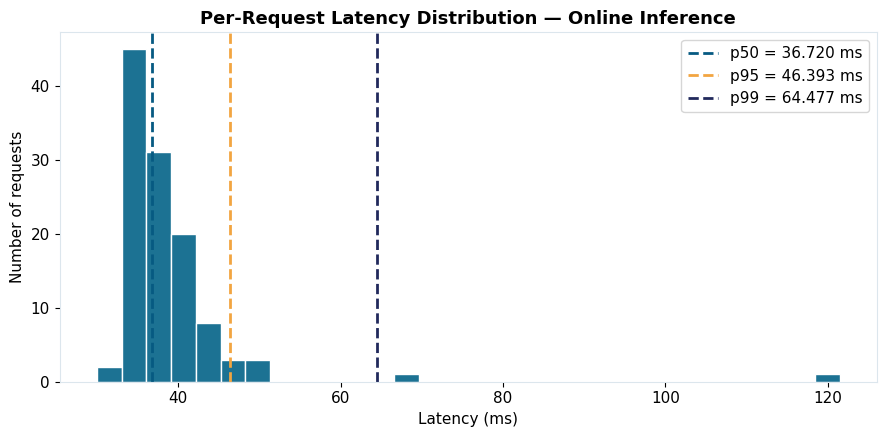

In [10]:
# Plot the distribution of online inference latency
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(online_latencies_ms, bins=30, color=COLOR_SECONDARY, edgecolor="white")

# Mark important latency percentiles
ax.axvline(p50, color=COLOR_PRIMARY, linestyle="--", linewidth=2, label=f"p50 = {p50:.3f} ms")
ax.axvline(p95, color=COLOR_ACCENT, linestyle="--", linewidth=2, label=f"p95 = {p95:.3f} ms")
ax.axvline(p99, color=COLOR_DARK, linestyle="--", linewidth=2, label=f"p99 = {p99:.3f} ms")
ax.set_title("Per-Request Latency Distribution — Online Inference", fontsize=13, fontweight="bold")
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Number of requests")
ax.legend()
plt.tight_layout()

# Save the chart for later use or reporting
plt.savefig("latency_histogram.png", dpi=150)
plt.show()

### Plot 2 — Percentile Bar Chart (matches the Module 2 slide format)

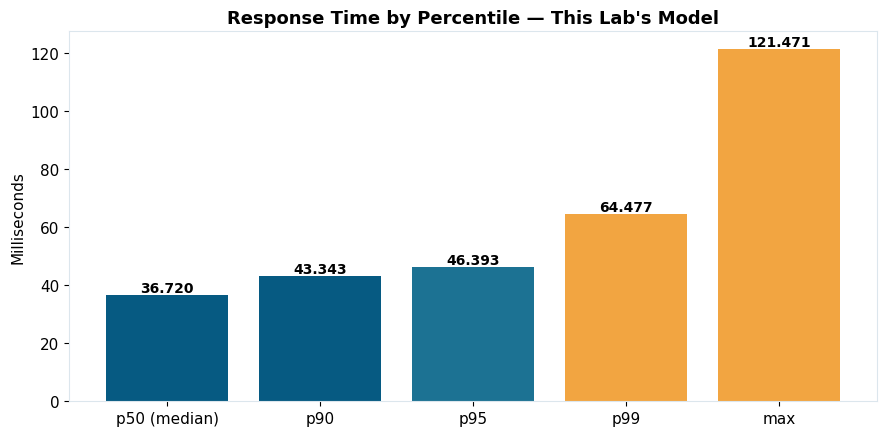

In [11]:
# Plot latency at different percentiles
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = percentile_summary["Percentile"]
values = percentile_summary["Latency (ms)"]
colors = [COLOR_PRIMARY, COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_ACCENT]

bars = ax.bar(labels, values, color=colors)
# Display the latency value above each bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Response Time by Percentile — This Lab's Model", fontsize=13, fontweight="bold")
ax.set_ylabel("Milliseconds")
plt.tight_layout()
# Save the chart for later reference
plt.savefig("latency_percentiles.png", dpi=150)
plt.show()


---
## Comparing Batch vs. Online

Same model. Same data. Same hardware. Two very different serving
patterns — and two very different performance profiles.

In [12]:
# Compare batch and online inference performance
comparison = pd.DataFrame({
    "Metric": [
        "Total time to score all records",
        "Average time per record",
        "Slowest single record (worst case)",
    ],
    "Batch": [
        f"{batch_total_time_ms:.2f} ms",
        f"{batch_total_time_ms / len(X_test):.4f} ms",
        "N/A — no per-record timing in a batch job",
    ],
    "Online": [
        f"{online_total_time_ms:.2f} ms",
        f"{online_latencies_ms.mean():.4f} ms",
        f"{p_max:.4f} ms (p99 = {p99:.4f} ms)",
    ],
})
comparison


,Metric,Batch,Online
0,Total time to score all records,104.18 ms,4412.21 ms
1,Average time per record,0.9138 ms,38.7036 ms
2,Slowest single record (worst case),N/A — no per-record timing in a batch job,121.4714 ms (p99 = 64.4773 ms)


### Reflection and Application Questions

1. **Batch vs. Online Efficiency**  
   Batch inference achieved a lower average processing cost per record. Why?  
   *Hint: Consider vectorized processing and the overhead of making separate function calls.*

2. **Why Does Latency Matter?**  
   Online inference provides per-request latency, including P99 and worst-case latency, while batch inference does not. Why would these metrics matter if the model were serving real-time patient risk scores instead of generating a nightly report?

3. **Meeting an SLA**  
   Suppose the online inference endpoint has a **5 ms P95 latency SLA**. Based on the results from this lab, does the system meet this requirement? What approaches could you investigate to reduce latency, such as caching, request batching, model optimization, or improved hardware?

4. **From Lab to Production**  
   This lab mainly changes how `predict()` is called. In a real production system, what other differences would you expect between a batch pipeline and an online inference service? Consider **infrastructure, monitoring, logging, failure handling, scalability, and deployment**.

---